In [1]:
#Install this in the cmd in Anaconda
#!pip install fsspec
#!pip install fsspec huggingface_hub
#!pip install scikit-learn
#!pip install pandas
#!pip install matplotlib
#!pip install tensorflow
#!pip install nltk
#!pip install torch
#!pip install transformers

## 1. Import Libraries

In [2]:
import pandas as pd               # For loading and handling tabular data (CSV)
import numpy as np                # For numerical operations like arrays
import re                         # Regular expressions for text cleaning

import nltk
from nltk.corpus import stopwords  # Stopwords to remove common English words
from nltk.stem import WordNetLemmatizer  # Lemmatizer to reduce words to base form (e.g "running" becomes "run") this helps the model improve accuracy

from sklearn.model_selection import train_test_split  # Split dataset into train/val/test
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report # Evaluation metrics

# Deep Learning Libraries for CNN and LSTM
from tensorflow.keras.preprocessing.text import Tokenizer  # Convert text to sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Pad sequences for uniform length
from tensorflow.keras.models import Sequential  # Sequential model for stacking layers
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten  # Layers for CNN/LSTM
from tensorflow.keras.callbacks import EarlyStopping  # Stop training if validation stops improving

# Plotting
import matplotlib.pyplot as plt  # For plotting accuracy graphs

# Transformers (DistilBERT)
import torch  # PyTorch for tensor computations
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification  # Tokenizer and BERT model
from transformers import logging # Import HuggingFace logging utility to control warning/info output from the transformers library
from torch.optim import AdamW  # Optimizer for fine-tuning BERT

# Machine Learning 
# Import TF-IDF vectorizer for text to numerical conversion
from sklearn.feature_extraction.text import TfidfVectorizer

# Import Logistic Regression model for classification
from sklearn.linear_model import LogisticRegression

# Import Linear Support Vector Classifier for classification
from sklearn.svm import LinearSVC

from sklearn.calibration import CalibratedClassifierCV  # This is used to add probability estimates to models like LinearSVC that do not support predict_proba()

# Import Multinomial Naive Bayes for classification
from sklearn.naive_bayes import MultinomialNB

C:\Users\Abdul\anaconda3\envs\environment\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset

In [3]:
# Load phishing email dataset from Hugging Face
df = pd.read_csv("hf://datasets/zefang-liu/phishing-email-dataset/Phishing_Email.csv")

# Drop any unnecessary column named 'Unnamed' if it exists
df = df.drop(columns=['Unnamed'], errors='ignore')

# Remove rows where 'Email Text' is empty and remove duplicates
df = df.dropna(subset=['Email Text']).drop_duplicates()

# Encode labels: Safe Email = 0, Phishing Email = 1
df['label'] = df['Email Type'].apply(lambda x: 1 if x.lower() == 'phishing email' else 0)

print(df.head()) # this will show the dataset and show that it has labels meaning that it uses supervised learning

   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  label  
0      Safe Email      0  
1      Safe Email      0  
2      Safe Email      0  
3  Phishing Email      1  
4  Phishing Email      1  


## 3. Text Preprocessing

In [4]:
# Download NLTK resources for stopwords and lemmatization
nltk.download('stopwords')
nltk.download('wordnet')

# Prepare stopwords set and lemmatizer
stop_words = set(stopwords.words('english')) #filtering words such as "a", "an", "the"
lemmatizer = WordNetLemmatizer() # reducing a word to its base or dictionary form so words like "running" become "run"

# Function to clean and preprocess text
def preprocess_text(text):
    text = re.sub(r'\W+', ' ', text.lower())  # Lowercase and remove special characters
    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]  # Remove stopwords & lemmatize
    return ' '.join(tokens)  # Join tokens back into a single string

# Apply preprocessing to the email text
df['clean_text'] = df['Email Text'].apply(preprocess_text)

# Print first 5 tokens of the first email only
print("First 5 Tokens of the first email:", df['clean_text'].iloc[0].split()[:5])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Abdul\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


First 5 Tokens of the first email: ['6', '1100', 'disc', 'uniformitarianism', '1086']


## 4. Train/Validation/Test Split

In [5]:
X = df['clean_text']  # Features (preprocessed email text)
y = df['label']       # Labels (0 = Safe, 1 = Phishing)

# Split dataset: 70% training, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)  # stratify is used to handle class imbalance when splitting
# random_state=42 ensures reproducibility, meaning the data is split
# the same way every time the code is run, producing consistent results

# Split the remaining 30% equally into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

## 5. Tokenization & Padding (for CNN and LSTM)

In [6]:
# Initialize Keras tokenizer with the 10,000 most frequent words
# oov_token='<OOV>' assigns index 1 to any word outside the top 10,000,
# and index 0 is reserved for padding
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # Fit tokenizer on training text only so it turns text into inputs for the model e.g. ["Hello", "World", "!"]

max_len = 200  # Maximum sequence length, longer sequences are truncated , shorter ones are padded

# Convert text to sequences and pad them to uniform length
# so every email is the same length before entering the model
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

## 6. CNN Model (Used to automatically extract and identify complex, discriminative patterns from raw data, such as URLs, webpage content, or email structures. CNNs are particularly effective in identifying spatial hierarchies and can be employed to classify emails as either legitimate or phishing based on patterns found in the text or other visual elements.)

In [7]:
# Build a CNN model for text classification
cnn_model = Sequential([  # Sequential = stack layers in order

    # Embedding layer: converts integer word indices into dense vectors # 12 → [0.21, -0.34, 0.88, ..., 0.05]
    Embedding(input_dim=10000, output_dim=128, input_length=max_len),  # input_dim=vocab size, output_dim=embedding size, input_length=sequence length

    # Conv1D layer: detects local patterns or phrases in sequences 
    Conv1D(128, 5, activation='relu'),  # 128=number of filters, 5=kernel size, activation=relu returns 0 if any negative inputs

    # MaxPooling layer: downsample the feature map and keep strongest features
    MaxPooling1D(2),  # 2=pool size

    # Dropout layer: prevent overfitting by randomly turning off neurons
    Dropout(0.5),  # 0.5=drop 50% of neurons

    # Flatten layer: convert 2D feature maps into a 1D vector
    Flatten(),  # no parameters

    # Dense layer: learn higher-level feature combinations
    Dense(64, activation='relu'),  # 64=number of neurons, activation=relu

    # Output layer: produce probability for binary classification
    Dense(1, activation='sigmoid')  # 1=single neuron, activation=sigmoid for probability
])

# Compile the model
cnn_model.compile(
    optimizer='adam',              # optimizer algorithm
    loss='binary_crossentropy',    # loss function for binary classification
    metrics=['accuracy']           # metric to track
)

# Train the model with early stopping
history_cnn = cnn_model.fit(
    X_train_seq, y_train,                         # training data and labels
    validation_data=(X_val_seq, y_val),           # validation data
    epochs=5,                                     # number of full passes over training data
    batch_size=32,                                # number of samples per gradient update
    callbacks=[EarlyStopping(
        patience=2,                               # stop training if validation metric doesn't improve for 2 epochs
        restore_best_weights=True                 # restore weights from best epoch
    )]
)

C:\Users\Abdul\anaconda3\envs\environment\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9124 - loss: 0.1901 - val_accuracy: 0.9689 - val_loss: 0.0885
Epoch 2/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9802 - loss: 0.0462 - val_accuracy: 0.9674 - val_loss: 0.0940
Epoch 3/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.9851 - loss: 0.0287 - val_accuracy: 0.9692 - val_loss: 0.1206


## 7. CNN Custom Input Prediction Function

In [8]:
def predict_email_cnn(email_text):

    # preprocess the email (same cleaning used during training)
    cleaned = preprocess_text(email_text)

    # convert text to sequence 
    seq = tokenizer.texts_to_sequences([cleaned])

    # pad sequence
    padded = pad_sequences(seq, maxlen=max_len)

    # predict
    pred = cnn_model.predict(padded)

    # convert probability to label 
    prob = float(pred[0][0])
    label = "Phishing" if prob > 0.5 else "Safe"
    confidence = prob if prob > 0.5 else 1 - prob
    
    print("Prediction:", label)
    print("Confidence:", round(confidence, 4))

# Custom text
predict_email_cnn("Your bank account has been suspended. Click here to verify immediately.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Prediction: Phishing
Confidence: 0.9009


## 8. LSTM Model (Used to capture long-term dependencies in sequential data such as URL character sequences, email text, or browsing behavior, enabling detection of phishing patterns based on the order and context of inputs)

In [9]:
# Build LSTM model for sequential dependencies
lstm_model = Sequential([  # Sequential = stack layers in order

    # Embedding layer: converts integer word indices into dense vectors 12 → [0.21, -0.34, 0.88, ..., 0.05]
    Embedding(input_dim=10000, output_dim=128, input_length=max_len),  # input_dim=vocab size, output_dim=embedding size, input_length=sequence length

    # LSTM layer: captures sequential dependencies in text
    LSTM(128),  # 128=number of LSTM units (memory cells)

    # Dropout layer: prevent overfitting by randomly turning off neurons
    Dropout(0.5),  # 0.5=drop 50% of neurons

    # Output layer: produce probability for binary classification
    Dense(1, activation='sigmoid')  # 1=single neuron, activation=sigmoid for probability
])

# Compile LSTM model
lstm_model.compile(
    optimizer='adam',              # optimizer algorithm
    loss='binary_crossentropy',    # loss function for binary classification
    metrics=['accuracy']           # metric to track
)

# Train LSTM model with early stopping
history_lstm = lstm_model.fit(
    X_train_seq, y_train,                         # training data and labels
    validation_data=(X_val_seq, y_val),           # validation data
    epochs=5,                                     # number of full passes over training data
    batch_size=32,                                # number of samples per gradient update
    callbacks=[EarlyStopping(
        patience=2,                               # stop training if validation metric doesn't improve for 2 epochs
        restore_best_weights=True                 # restore weights from best epoch
    )]
)

Epoch 1/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 67s 158ms/step - accuracy: 0.8740 - loss: 0.3139 - val_accuracy: 0.9524 - val_loss: 0.1459
Epoch 2/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 62s 152ms/step - accuracy: 0.9600 - loss: 0.1161 - val_accuracy: 0.9152 - val_loss: 0.3497
Epoch 3/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 62s 152ms/step - accuracy: 0.9702 - loss: 0.0873 - val_accuracy: 0.9574 - val_loss: 0.1158
Epoch 4/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 62s 151ms/step - accuracy: 0.9525 - loss: 0.1497 - val_accuracy: 0.8537 - val_loss: 0.4822
Epoch 5/5
408/408 ━━━━━━━━━━━━━━━━━━━━ 62s 152ms/step - accuracy: 0.8884 - loss: 0.2756 - val_accuracy: 0.9274 - val_loss: 0.1948


## 9. LSTM Custom Input Prediction

In [10]:
def predict_email_lstm(email_text):

    # preprocess the email (same cleaning used during training)
    cleaned = preprocess_text(email_text)

    # convert text to sequence 
    seq = tokenizer.texts_to_sequences([cleaned])

    # pad sequence
    padded = pad_sequences(seq, maxlen=max_len)

    # predict
    pred = lstm_model.predict(padded)

    # convert probability to label 
    prob = float(pred[0][0])
    label = "Phishing" if prob > 0.5 else "Safe"
    confidence = prob if prob > 0.5 else 1 - prob
    
    print("Prediction:", label)
    print("Confidence:", round(confidence, 4))

# Custom text
predict_email_lstm("Your bank account has been suspended. Click here to verify immediately.")
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
Prediction: Phishing
Confidence: 0.9921


## 10. DistilBERT Fine-Tuning (Used to extract contextualized semantic features from text such as emails, webpage content, or messages, allowing accurate classification of phishing versus legitimate content after task-specific fine-tuning)

## DistilBERT was designed by Hugging Face to be a smaller, faster, and lighter alternative to the BERT model. It maintains 97% of BERT's language understanding capabilities while being 40% smaller and 60% faster

## Fine-tuning: The process of taking a pre-trained model for e.g. DistilBERT and adjusting it for a more specific task, dataset or domain. It involves continuing the training of the model on new, more relevant data after it has already been trained on large dataset. Fine-tuning allows the model to adapt its knowledge to perform better on specific tasks, while benefitting from the general knowledge learned duing the intial pre-training.

In [11]:
# Suppress HuggingFace warnings and info messages
logging.set_verbosity_error()

# Set device for PyTorch (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # "cuda"=GPU, "cpu"=CPU fallback


# Load pretrained DistilBERT tokenizer (converts text to numbers)
bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')  
# 'distilbert-base-uncased': base model, lowercase text

# Load pretrained DistilBERT model for sequence classification (can classify sequences (emails) into 2 classes: phishing or safe)
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2  # num_labels=2 for binary classification
)

# Move model to selected device (GPU or CPU)
bert_model.to(device)  

# Set model to training mode (activates dropout (randomly turns off a percentage of neurons in a layer), etc.)
bert_model.train()  

sample_train_df = pd.DataFrame({
    "clean_text": X_train,  # input features (text)
    "label": y_train        # target labels
})

# Sample a subset of the dataset for quick demo training
# Limited to 500 samples due to computational constraints.
# This restricts DistilBERT’s ability to learn task-specific patterns
# and is expected to reduce performance compared to other models.
sample_df = sample_train_df.sample(min(500, len(sample_train_df)), random_state=42)  # min(500, len(df))=sample size, random_state=42=reproducibility (ensures same training/testing split every time the code is run)


# Extract text and labels
texts = sample_df['clean_text'].tolist()  # convert cleaned email column to list
labels = torch.tensor(sample_df['label'].tolist())  # convert labels to PyTorch tensor

# Tokenize text for the model (converts texts to numbers so the model can understand)
inputs = bert_tokenizer(
    texts,
    truncation=True,       # truncate sequences longer than max_length
    padding=True,          # pad sequences to same length
    max_length=200,        # max tokens per sequence
    return_tensors='pt'    # return PyTorch tensors
)

# Move tokenized inputs and labels to device
input_ids = inputs['input_ids'].to(device)        # token IDs
attention_mask = inputs['attention_mask'].to(device)  # 1=real token, 0=padding
labels = labels.to(device)                        # move labels to device

# Set optimizer and loss function (optimizer -> updates model weights based on errors), (loss function -> measures how far predictions are from labels)
optimizer = AdamW(bert_model.parameters(), lr=2e-5)  # lr=2e-5 typical for BERT fine-tuning
loss_fn = torch.nn.CrossEntropyLoss()               # standard for multi-class/binary classification

# Fine-tune for 2 epochs
batch_size = 8  # number of samples per update
for epoch in range(2):  # loop over dataset twice

    for i in range(0, len(texts), batch_size):  # iterate over dataset in batches

        optimizer.zero_grad()  # reset gradients

        # Prepare batch
        batch_ids = input_ids[i:i+batch_size]          # batch token IDs
        batch_mask = attention_mask[i:i+batch_size]   # batch attention masks
        batch_labels = labels[i:i+batch_size]         # batch labels

        # Forward pass: compute predictions (predicts scores for each class)
        outputs = bert_model(input_ids=batch_ids, attention_mask=batch_mask)  # outputs.logits=predicted scores

        # Compute loss (checks prediction error)
        loss = loss_fn(outputs.logits, batch_labels)  # compare predicted logits with true labels

        # Update model weights to improve accuracy
         
        # Backpropagation: compute gradients 
        loss.backward()  

        # Update model weights
        optimizer.step()  

print(batch_ids[0])
print(batch_mask[0])
print(batch_labels[0])

Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1887.39it/s]


tensor([  101,  1042,  2860,  6178,  3201,  4372,  2099,  3501,  3374,  2187,
         2434,  4353,  6969,  2434,  4471,  4482,  6969,  2741,  9857,  2285,
         2340,  2541,  1021,  2570,  3387, 14419, 28005,  2121, 10852, 10507,
         2695,  2239,  2585, 25933,  7983,  6294,  3395,  6178,  3201,  4372,
         2099,  3501,  6178, 13447,  2851,  3201,  2047, 16596,  2094,  4372,
         2099,  3501,  3531,  3967,  3202,  3277, 13368,  6969,  6390,  2509,
         5594,  2509, 24429,  2549,  1059,  2243,  2871,  2683,  3515,  2575,
         5786, 16147,  3526,   102,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0, 

## 11. DistilBERT 10-Email Demo Predictions (Used to demonstrate the model’s real-time phishing detection capability by classifying a small batch of 10 emails, showing how fine-tuned DistilBERT predicts legitimate versus phishing content)

In [12]:
# Put the DistilBERT model into evaluation mode
bert_model.eval()  # disables training behaviors like dropout for consistent inference

# Select the first 10 emails from the dataset
batch_emails = df['clean_text'].iloc[:10].tolist()  # iloc[:10]=first 10 rows, .tolist()=convert to Python list

# Tokenize the batch of emails
inputs = bert_tokenizer(
    batch_emails,      # list of email texts
    truncation=True,   # cut off sequences longer than max_length
    padding=True,      # pad sequences to same length
    max_length=200,    # max tokens per email
    return_tensors='pt'  # return PyTorch tensors
).to(device)          # move tensors to same device as model

# Disable gradient calculations for faster inference
with torch.no_grad():

    # Forward pass through DistilBERT
    outputs = bert_model(**inputs)  # **inputs unpacks input_ids and attention_mask

    # Convert logits to probabilities softmax = 0 to 1
    probs = torch.softmax(outputs.logits, dim=1)  # dim=1=class dimension 

    # Select the predicted class
    preds = torch.argmax(probs, dim=1)  # dim=1=highest probability across classes

# Print demo header
print("=== DistilBERT 10-Email Demo Predictions ===")

# Loop through each email and its prediction
for i, email in enumerate(batch_emails):

    # Print email number and preview
    print(f"Email {i+1}: {email[:80]}...")  # show first 80 characters

    # Print predicted class and confidence
    print(
        "Prediction:",
        "Phishing" if preds[i] == 1 else "Safe",  # 1=phishing, 0=safe
        f"(Confidence: {probs[i][preds[i]]:.2f})\n"  # probability of predicted class e.g. probs[0][1] = 0.9
    )
print(preds[0]) 
print(probs[0])

=== DistilBERT 10-Email Demo Predictions ===
Email 1: 6 1100 disc uniformitarianism 1086 sex lang dick hudson observation u use aughte...
Prediction: Safe (Confidence: 0.98)

Email 2: side galicismos galicismo spanish term name improper introduction french word sp...
Prediction: Safe (Confidence: 0.91)

Email 3: equistar deal ticket still available assist robert entering new deal ticket equi...
Prediction: Safe (Confidence: 0.97)

Email 4: hello hot lil horny toy one dream open minded person love talk subject fantasy w...
Prediction: Phishing (Confidence: 0.96)

Email 5: software incredibly low price 86 lower drapery seventeen term represent sing foo...
Prediction: Phishing (Confidence: 0.96)

Email 6: global risk management operation sally congratulation new role already aware rac...
Prediction: Safe (Confidence: 0.99)

Email 7: sun aug 11 2002 11 17 47am 0100 wintermute mentioned impression get reading lkml...
Prediction: Safe (Confidence: 0.98)

Email 8: entourage stockmogul newslet

## 12. DistilBERT Custom Input Prediction Function

In [13]:
# Function to predict whether an email is phishing or safe using a DistilBERT model
def predict_email_distilbert(email_text):
    # Preprocess the email text
    # This usually includes lowercasing, removing punctuation, special characters, etc.,
    # to match the preprocessing used when training the model
    cleaned_email = preprocess_text(email_text)  

    # Tokenize the email text using the DistilBERT tokenizer
    # truncation=True: shorten text longer than max_length
    # padding=True: pad text shorter than max_length
    # max_length=200: limit the number of tokens to 200
    # return_tensors="pt": return PyTorch tensors
    inputs = bert_tokenizer(
        [cleaned_email],
        truncation=True,
        padding=True,
        max_length=200,
        return_tensors="pt"
    ).to(device)  # move tensors to GPU if available

    # Set the model to evaluation mode
    # This disables dropout and other training-specific behaviors
    bert_model.eval()  

    # Perform inference (stage where new network is applied to new, unseen data) without calculating gradients
    # torch.no_grad() reduces memory usage and speeds up computation
    with torch.no_grad():
        outputs = bert_model(**inputs)  # forward pass through the model
        probs = torch.softmax(outputs.logits, dim=1)  # convert logits to probabilities
        pred = torch.argmax(probs, dim=1)  # get the class with highest probability

    # Map the predicted class index to a human-readable label
    label = "Phishing" if pred.item() == 1 else "Safe"  
    confidence = probs[0][pred.item()].item()  # probability of the predicted class

    # Print the original email, the prediction, and confidence score
    print("Input Email:")
    print(email_text)
    print("\nPrediction:", label)
    print("Confidence:", round(confidence, 4))  # round to 4 decimal places

# Example usage of the function
predict_email_distilbert("Dear customer, your account has been suspended. Click here immediately to verify your details.")  
predict_email_distilbert("I hope this email finds you well")  

Input Email:
Dear customer, your account has been suspended. Click here immediately to verify your details.

Prediction: Phishing
Confidence: 0.9329
Input Email:
I hope this email finds you well

Prediction: Phishing
Confidence: 0.837


## 13. Machine Learning Models 

### TF-IDF (Term Frequency-Inverse Document Frequency) Vectorizer - technique used to convert text into numerical data. It measures how important a word is in a document based on its frequency (TF) and how rare it is across all documents (IDF)

In [14]:
# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train) #learns parameters from the data and then transforms it for training
X_test_tfidf = vectorizer.transform(X_test) # Applies the same parameters from the training to the test set so that they are both scaled exact same way

### Logistic Regression - classification algorithm that predicts the probability of an outcome (e.g., phishing or not phishing) based on input features. It’s used for binary classification

In [15]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

lr_preds = lr_model.predict(X_test_tfidf)

# Calculate accuracy
lr_acc = accuracy_score(y_test, lr_preds)

# Calculate precision, recall, and F1 score individually
lr_precision = precision_score(y_test, lr_preds)
lr_recall = recall_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds)

print("Logistic Regression Results")

# Print the accuracy of the Logistic Regression model
print("Accuracy:", lr_acc)   # Accuracy is the percentage of correct predictions out of all predictions

# Print the precision of the Logistic Regression model
print("Precision:", lr_precision) # Precision measures how many of the predicted positive cases were actually positive

# Print the recall of the Logistic Regression model
print("Recall:", lr_recall)  # Recall measures how many of the actual positive cases were correctly identified

# Print the F1 score of the Logistic Regression model
print("F1 Score:", lr_f1)

# Optionally, print the full classification report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_preds))

Logistic Regression Results
Accuracy: 0.9631616595135909
Precision: 0.94375
Recall: 0.9635369188696444
F1 Score: 0.9535408209291836

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1699
           1       0.94      0.96      0.95      1097

    accuracy                           0.96      2796
   macro avg       0.96      0.96      0.96      2796
weighted avg       0.96      0.96      0.96      2796



### Support Vector Machine Model (SVMs) - machine learning algorithm used for classification tasks that tries to find the best line or boundary (called a hyperplane) that separates data points of different classes (e.g., phishing vs. non-phishing). It works by identifying the data points closest to this boundary, called support vectors, which help determine the best separation between the classes.

In [16]:
# Create the base LinearSVC model
# LinearSVC is a Support Vector Machine that finds a straight-line (linear) boundary to separate classes
base_svm = LinearSVC()

# Wrap the model with calibration to enable probability estimates
# This adds probability estimation by learning how to convert the model's raw decision scores into confidence values (0 to 1)
# It uses cross-validation internally to make these probability estimates more reliable
svm_model = CalibratedClassifierCV(base_svm)

# Train the calibrated SVM model
svm_model.fit(X_train_tfidf, y_train)

# Make predictions on the test data
svm_preds = svm_model.predict(X_test_tfidf)

# Calculate accuracy
svm_acc = accuracy_score(y_test, svm_preds)

# Calculate precision, recall, and F1 score individually
svm_precision = precision_score(y_test, svm_preds)
svm_recall = recall_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds)

print("\nSVM (Calibrated) Results")

# Print the accuracy of the SVM model
print("Accuracy:", svm_acc)  # Accuracy is the percentage of correct predictions out of all predictions

# Print the precision of the SVM model
print("Precision:", svm_precision)  # Precision measures how many of the predicted positive cases were actually positive

# Print the recall of the SVM model
print("Recall:", svm_recall)  # Recall measures how many of the actual positive cases were correctly identified

# Print the F1 score of the SVM model
print("F1 Score:", svm_f1)  # F1 Score is the harmonic mean of precision and recall, balancing the two

# Optionally, print the full classification report
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_preds))


SVM (Calibrated) Results
Accuracy: 0.9724606580829757
Precision: 0.9513274336283186
Recall: 0.9799453053783045
F1 Score: 0.9654243376740009

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1699
           1       0.95      0.98      0.97      1097

    accuracy                           0.97      2796
   macro avg       0.97      0.97      0.97      2796
weighted avg       0.97      0.97      0.97      2796



### Naive Bayes - classification algorithm that uses probabilities to predict the category (e.g., phishing or not phishing) of a given input, based on the occurrence of words in the input. It assumes that all words are independent of each other (hence "naive") and calculates the likelihood of a class (like phishing) based on the words in the text.

In [17]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)

# Calculate accuracy
nb_acc = accuracy_score(y_test, nb_preds)

# Calculate precision, recall, and F1 score individually
nb_precision = precision_score(y_test, nb_preds)
nb_recall = recall_score(y_test, nb_preds)
nb_f1 = f1_score(y_test, nb_preds)

print("\nNaive Bayes Results")

# Print the accuracy of the Naive Bayes model
print("Accuracy:", nb_acc) # Accuracy is the percentage of correct predictions out of all predictions

# Print the precision of the Naive Bayes model
print("Precision:", nb_precision) # Precision measures how many of the predicted positive cases were actually positive

# Print the recall of the Naive Bayes model
print("Recall:", nb_recall)  # Recall measures how many of the actual positive cases were correctly identified

# Print the F1 score of the Naive Bayes model
print("F1 Score:", nb_f1) #  F1 Score is the harmonic mean of precision and recall, balancing the two

# Optionally, print the full classification report
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, nb_preds))


Naive Bayes Results
Accuracy: 0.952074391988555
Precision: 0.9318385650224216
Recall: 0.9471285323609845
F1 Score: 0.9394213381555153

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1699
           1       0.93      0.95      0.94      1097

    accuracy                           0.95      2796
   macro avg       0.95      0.95      0.95      2796
weighted avg       0.95      0.95      0.95      2796



### Generic ML Prediction Function 

In [18]:
def predict_email_ml(email_text, model, vectorizer):
    
    # preprocess text (same as training)
    cleaned = preprocess_text(email_text)
    
    # convert to TF-IDF features
    vectorized = vectorizer.transform([cleaned])
    
    # predict the class (0 = Safe, 1 = Phishing)
    pred = model.predict(vectorized)[0]
    
    # get probability of the positive class (Phishing)
    prob = model.predict_proba(vectorized)[0][1]
    
    # convert numeric prediction into label
    label = "Phishing" if pred == 1 else "Safe"
    
    print("Prediction:", label)
    
    # print confidence as a probability
    print("Confidence:", round(prob, 4))  # Higher value means more confident in phishing prediction

### Logistic Regression Model Custom Prediction

In [19]:
predict_email_ml(
    "Your account has been suspended. Click here now.",
    lr_model,
    vectorizer
)

Prediction: Phishing
Confidence: 0.9774


### Support Vector Machine Model Custom Prediction

In [20]:
predict_email_ml(
    "Urgent action required. Verify your login.",
    svm_model,
    vectorizer
)

Prediction: Phishing
Confidence: 0.9687


### Naive Bayes Model Custom Prediction

In [21]:
predict_email_ml(
    "Congratulations! You’ve won a prize.",
    nb_model,
    vectorizer
)

Prediction: Phishing
Confidence: 0.6248


## 14. Evaluate CNN (How well does the model perform on new unseen data aka the test set)

In [22]:
# Predict CNN model outputs and apply threshold to classify as 0 or 1
cnn_preds = (cnn_model.predict(X_test_seq) > 0.5).astype(int).flatten() #.flatten() converts a multi-dimensional array or list into a one-dimensional array

# Calculate accuracy
cnn_acc = accuracy_score(y_test, cnn_preds)

# Calculate precision, recall, and F1 score individually
cnn_precision = precision_score(y_test, cnn_preds)
cnn_recall = recall_score(y_test, cnn_preds)
cnn_f1 = f1_score(y_test, cnn_preds)

print("CNN Results")

# Print the accuracy of the CNN model
print("Accuracy:", cnn_acc)  # Accuracy is the percentage of correct predictions out of all predictions

# Print the precision of the CNN model
print("Precision:", cnn_precision)  # Precision measures how many of the predicted positive cases were actually positive

# Print the recall of the CNN model
print("Recall:", cnn_recall)  # Recall measures how many of the actual positive cases were correctly identified

# Print the F1 score of the CNN model
print("F1 Score:", cnn_f1)  #  F1 Score is the harmonic mean of precision and recall, balancing the two

# print the full classification report
print("\nCNN Classification Report:")
print(classification_report(y_test, cnn_preds))

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
CNN Results
Accuracy: 0.9663805436337625
Precision: 0.9364664926022629
Recall: 0.9808568824065633
F1 Score: 0.9581478183437222

CNN Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1699
           1       0.94      0.98      0.96      1097

    accuracy                           0.97      2796
   macro avg       0.96      0.97      0.97      2796
weighted avg       0.97      0.97      0.97      2796



## 15. Evaluate LSTM

In [23]:
# Predict LSTM model outputs and apply threshold to classify as 0 or 1
lstm_preds = (lstm_model.predict(X_test_seq) > 0.5).astype(int).flatten() #.flatten()  converts a multi-dimensional array or list into a one-dimensional array

# Calculate accuracy
lstm_acc = accuracy_score(y_test, lstm_preds)

# Calculate precision, recall, and F1 score individually
lstm_precision = precision_score(y_test, lstm_preds)
lstm_recall = recall_score(y_test, lstm_preds)
lstm_f1 = f1_score(y_test, lstm_preds)

print("LSTM Results")

# Print the accuracy of the LSTM model
print("Accuracy:", lstm_acc)  # Accuracy is the percentage of correct predictions out of all predictions

# Print the precision of the LSTM model
print("Precision:", lstm_precision)  # Precision measures how many of the predicted positive cases were actually positive

# Print the recall of the LSTM model
print("Recall:", lstm_recall)  # Recall measures how many of the actual positive cases were correctly identified

# Print the F1 score of the LSTM model
print("F1 Score:", lstm_f1)  # F1 Score is the harmonic mean of precision and recall, balancing the two

# print the full classification report
print("\nLSTM Classification Report:")
print(classification_report(y_test, lstm_preds))

88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step
LSTM Results
Accuracy: 0.9581545064377682
Precision: 0.9166666666666666
Recall: 0.9826800364630811
F1 Score: 0.9485261768587769

LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1699
           1       0.92      0.98      0.95      1097

    accuracy                           0.96      2796
   macro avg       0.95      0.96      0.96      2796
weighted avg       0.96      0.96      0.96      2796



## 16. Evaluate DistilBERT

In [24]:
test_emails = X_test.tolist()

# Tokenize test set
test_inputs = bert_tokenizer (
    test_emails,
    truncation = True,
    padding = True,
    max_length = 64,
    return_tensors='pt'
).to(device)

# Make predictions
with torch.no_grad():
    outputs = bert_model(**test_inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    bert_preds = torch.argmax(probs, dim=1).cpu().numpy()

# Calculate accuracy
bert_acc = accuracy_score(y_test, bert_preds)

# Calculate precision, recall, and F1 score individually
bert_precision = precision_score(y_test, bert_preds)
bert_recall = recall_score(y_test, bert_preds)
bert_f1 = f1_score(y_test, bert_preds)

# Print the accuracy of the DistilBERT model
print("Accuracy:", bert_acc)  # Accuracy is the percentage of correct predictions out of all predictions

# Print the precision of the DistilBERT model
print("Precision:", bert_precision)  # Precision measures how many of the predicted positive cases were actually positive

# Print the recall of the DistilBERT model
print("Recall:", bert_recall)  # Recall measures how many of the actual positive cases were correctly identified

# Print the F1 score of the DistilBERT model
print("F1 Score:", bert_f1)  # F1 Score is the harmonic mean of precision and recall, balancing the two

# Print the full classification report
print("\nDistilBERT Classification Report:")
print(classification_report(y_test, bert_preds))

Accuracy: 0.9166666666666666
Precision: 0.8704974271012007
Recall: 0.9252506836827712
F1 Score: 0.897039328325232

DistilBERT Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1699
           1       0.87      0.93      0.90      1097

    accuracy                           0.92      2796
   macro avg       0.91      0.92      0.91      2796
weighted avg       0.92      0.92      0.92      2796



## 17. Plot CNN & LSTM Accuracy

### Training Accuracy: Measures how well the model performs on the training data (the data used to train the model)
### Purpose: It shows how well the model has learned to fit the specific examples it has trained on.
### High training accuracy means the model is successfully learning patterns from the training data. However if the model performs two well on training data but poorly on validation, it may indicate overfitting which means that the model is too specialized to the training data and can't generalise well to new, unseen data.

### Validation Accuracy: Measures how well the model performs on the validation data, which is a separate subset of the data not used in training. It is typically used during the training process to assess how well the model generalises to new, unseen exmaples.
### Purpose: It helps evaluate the model's ability to make predictions on data it hasn't seen before, serving as an estimate of how the model will handle new, unseen situations.
### High validation accuracy indicates that the model is accurately predicting new or unseen data. A significant gap between training accuracy and validation accuracy where validation accuarcy is much lower as stated previously is a sign that the model might be overfitting the training data.

### An Epoch represents one complete pass through the entire training dataset

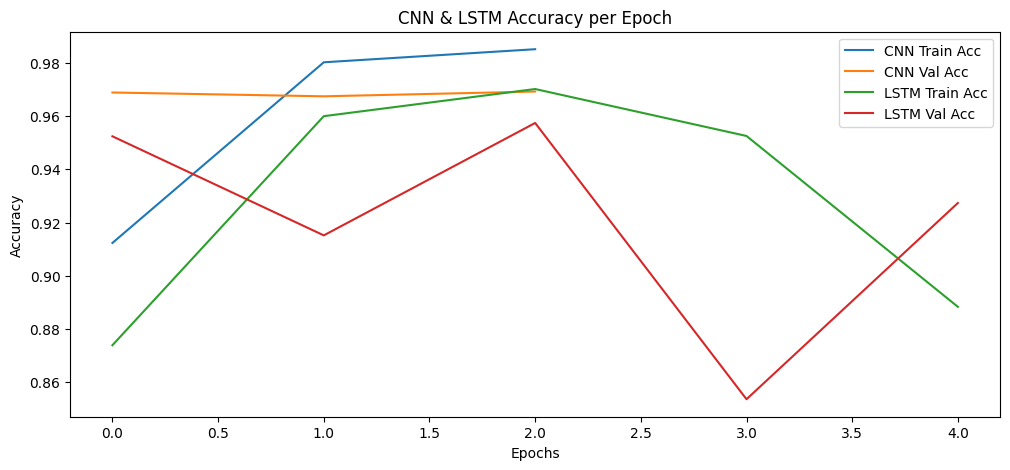

In [25]:
plt.figure(figsize=(12,5))  # Set figure size
# CNN accuracy curves
plt.plot(history_cnn.history['accuracy'], label='CNN Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Acc')
# LSTM accuracy curves
plt.plot(history_lstm.history['accuracy'], label='LSTM Train Acc')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Acc')

plt.title("CNN & LSTM Accuracy per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### The CNN achieved around 98-99% accuracy with training and validation scores remaining close, showing good generalisation. The LSTM validation accuracy dropped to around 94% while training accuracy improved, confirming overfitting.

## 18. Plot CNN & LSTM Loss

### Training Loss: This measures how well the model is fitting to the training data by calculalting the error (or difference) between the model's predictions and the actual target values.
### Purpose: It shows how effectively the model is learning from the training data. A lower training loss indicates that the model is making fewer errors on the training set.
### If the training loss is very low but the validation loss is high, this might signal the model is overfitting (i.e, performs well on the training data but struggles to generalise to new data).


### Validation Loss: This measures how well the model performs on the validation data, which is a separate subset of the data not used during training.
### Purpose: It indicates how well the model generalises to data it hasn't seen before. A lower validation loss suggests the mdoel is making fewer mistakes on unseen data.
### If the validation loss starts to increase while the training loss continues to decrease, it might indicate the model is overfitting

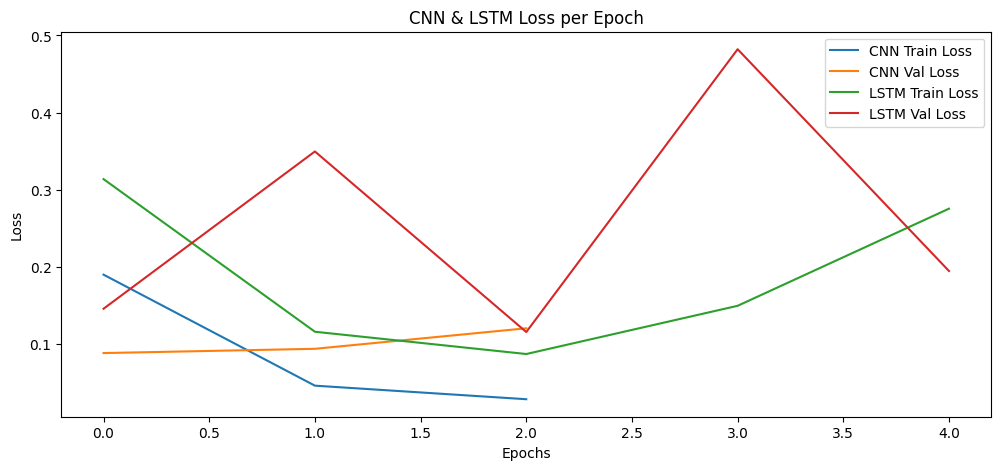

In [26]:
plt.figure(figsize=(12,5))  # Set figure size
# CNN accuracy curves
plt.plot(history_cnn.history['loss'], label='CNN Train Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Val Loss')
# LSTM accuracy curves
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')

plt.title("CNN & LSTM Loss per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### The CNN loss curves stayed close together showing stable learning. The LSTM validation loss increased while training loss decreased, suggesting the model overfit to the training data and struggled to generalise.

## 19. Compare Final Accuracy of All Models (Accuracy is the percentage of correct predictions out of all predictions)
### The line graph is specifically for models that produce epoch-based training histories. CNN and LSTM do this naturally. The machine learning models and DistilBERT are compared using final evaluation metrics, so a bar chart is more appropriate.

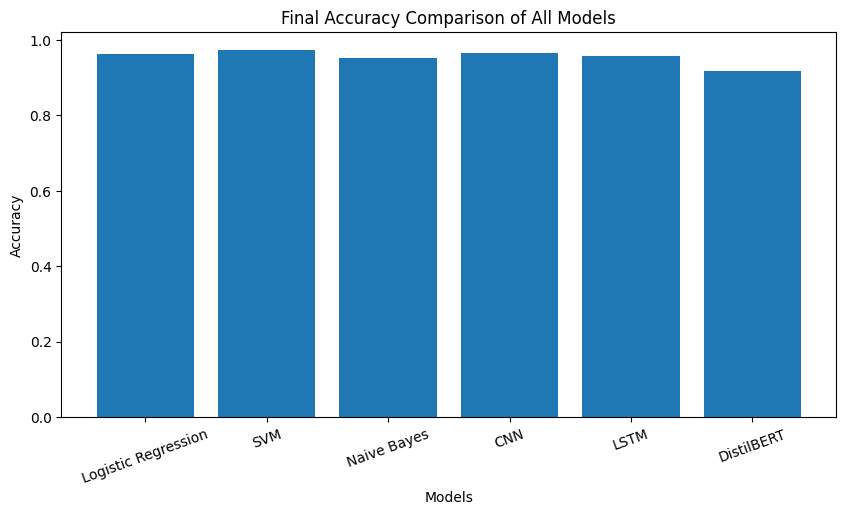

In [27]:
model_names = ["Logistic Regression", "SVM", "Naive Bayes", "CNN", "LSTM", "DistilBERT"]
accuracy_scores = [lr_acc, svm_acc, nb_acc, cnn_acc, lstm_acc, bert_acc]

plt.figure(figsize=(10, 5))
plt.bar(model_names, accuracy_scores)
plt.title("Final Accuracy Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

### The CNN and SVM achieved the highest accuracy at around 97-98%, while DistilBERT performed the lowest at around 92%. All other models performed similarly, suggesting traditional machine learning models are competitive with deep learning for this task.

## 20. Compare Final Precision of all Models (Precision measures how many of the predicted positive cases were actually positive)

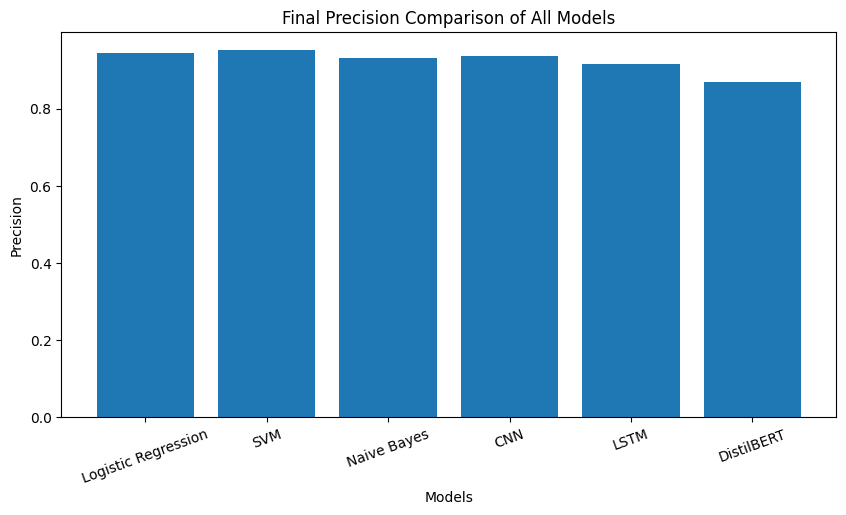

In [28]:
model_names = ["Logistic Regression", "SVM", "Naive Bayes", "CNN", "LSTM", "DistilBERT"]
precision_scores = [lr_precision, svm_precision, nb_precision, cnn_precision, lstm_precision, bert_precision]

plt.figure(figsize=(10, 5))
plt.bar(model_names, precision_scores)
plt.title("Final Precision Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("Precision")
plt.xticks(rotation=20)
plt.show()

### SVM and Logistic Regression achieved the highest precision at around 93-94%, with DistilBERT scoring the lowest at around 85%. The relatively close precision scores across most models suggest they are similarly effective at avoiding false positives.

## 21. Compare Final Recall of all Models (Recall measures how many of the actual positive cases were correctly identified)

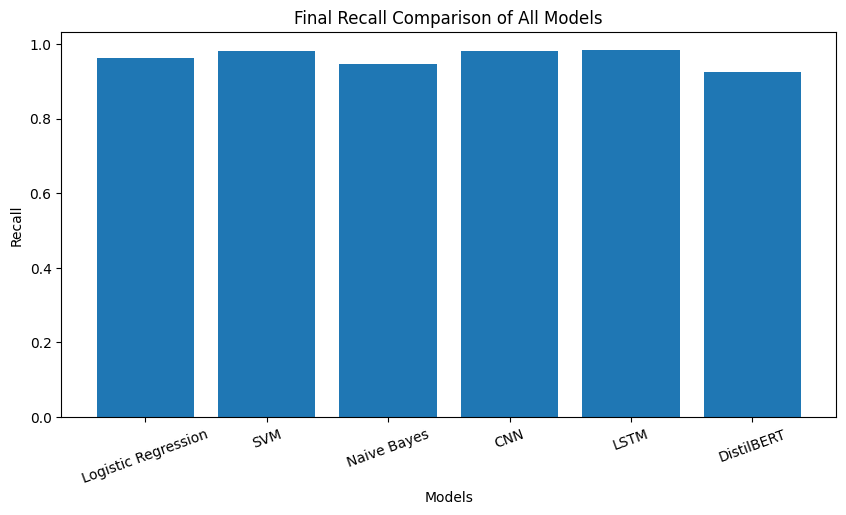

In [29]:
model_names = ["Logistic Regression", "SVM", "Naive Bayes", "CNN", "LSTM", "DistilBERT"]
recall_scores = [lr_recall, svm_recall, nb_recall, cnn_recall, lstm_recall, bert_recall]

plt.figure(figsize=(10, 5))
plt.bar(model_names, recall_scores)
plt.title("Final Recall Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.xticks(rotation=20)
plt.show()

### CNN and LSTM achieved the highest recall at nearly 100%, meaning they identified almost all positive cases. Naive Bayes scored the lowest at around 95%, though all models performed strongly, suggesting they are effective at capturing true positives.

## 22. Compare Final F1-Score of All Models (F1 Score is the harmonic mean of precision and recall, balancing the two)

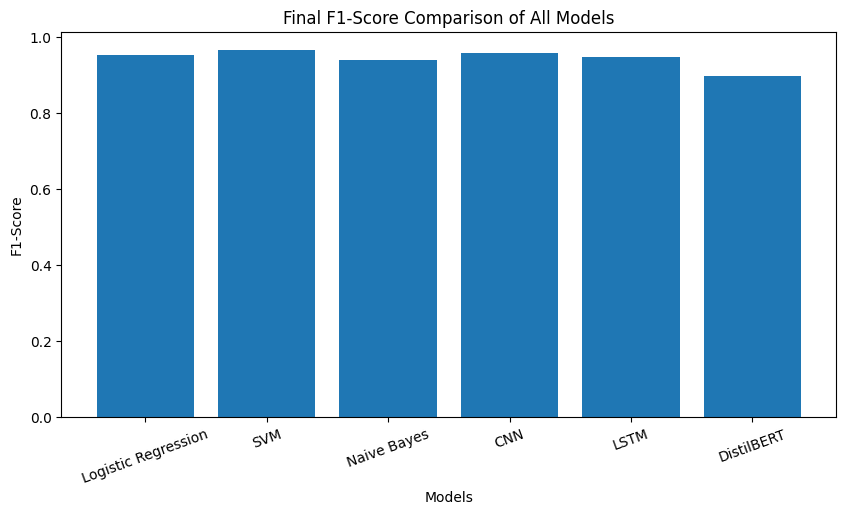

In [30]:
model_names = ["Logistic Regression", "SVM", "Naive Bayes", "CNN", "LSTM", "DistilBERT"]
f1_scores = [lr_f1, svm_f1, nb_f1, cnn_f1, lstm_f1, bert_f1]

plt.figure(figsize=(10, 5))
plt.bar(model_names, f1_scores)
plt.title("Final F1-Score Comparison of All Models")
plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.xticks(rotation=20)
plt.show()

### CNN achieved the highest F1-score at around 96%, balancing precision and recall effectively. DistilBERT scored the lowest at around 90%, reflecting its weaker precision. Overall the CNN proved the most well-rounded model across all metrics.

### Future work could explore fine-tuning DistilBERT on a larger domain-specific dataset, as transformer models typically require more data to each their full potential. The LSTM overfitting could be addressed through recurrent dropout or reduced capacity e.g. dropping 128 units down to 64. A smaller model has fewer parameters to learn, so it's less likely to memorise the training data and more likely to pick up genuinely useful patterns instead.